## IMPORTING LIBRARIES

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sqlite3

## CONNECTING TO THE DATABASE

In [54]:
conn = sqlite3.connect('chinook.db')

## Verifying if the tables exist and have rows

In [55]:
query = "SELECT name FROM sqlite_master WHERE type = 'table';"
pd.read_sql(query , conn)

,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack


## Which Country Has more Customers

In [56]:
# Where the customers are from
query = """
    SELECT Country , COUNT(CustomerID) as Customer_count
    FROM Customer
    GROUP BY Country
    ORDER BY Customer_count DESC;

"""
chinook_customers = pd.read_sql(query , conn)
chinook_customers

,Country,Customer_count
0,USA,13
1,Canada,8
2,France,5
3,Brazil,5
4,Germany,4
5,United Kingdom,3
6,Portugal,2
7,India,2
8,Czech Republic,2
9,Sweden,1


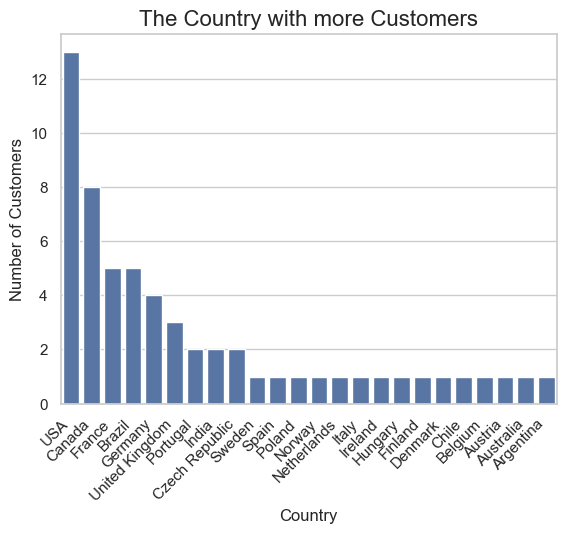

In [57]:
plt.Figure(figsize=(12 , 6))
sns.barplot(data=chinook_customers , x='Country' , y='Customer_count')
plt.title('The Country with more Customers' , fontsize = 16)
plt.xlabel('Country', fontsize = 12)
plt.ylabel('Number of Customers')
plt.xticks(rotation = 45 , ha = "right")
plt.show()

## Which Genre of Music Generates the more Money

In [58]:
# Which Genre generates the more money
query = """
    SELECT g.Name AS Genre , SUM(il.UnitPrice*il.Quantity) AS TotalRevenue
    From Genre g
    JOIN Track t ON g.GenreId = t.GenreId
    JOIN InvoiceLine il ON t.TrackId = il.TrackId
    GROUP BY 1
    ORDER BY TotalRevenue DESC ;
"""
chinook_genre = pd.read_sql(query , conn)
chinook_genre

,Genre,TotalRevenue
0,Rock,826.65
1,Latin,382.14
2,Metal,261.36
3,Alternative & Punk,241.56
4,TV Shows,93.53
5,Jazz,79.20
6,Blues,60.39
7,Drama,57.71
8,R&B/Soul,40.59
9,Classical,40.59


C:\Users\HP\AppData\Local\Temp\ipykernel_16664\1824665501.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chinook_genre , x = 'TotalRevenue' , y = 'Genre' , palette='viridis')


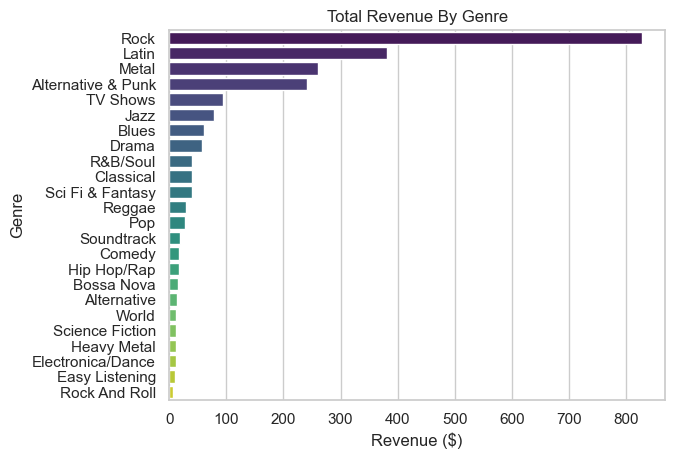

In [59]:
sns.set_theme(style='whitegrid')
plt.Figure(figsize=(12 , 6))
sns.barplot(data=chinook_genre , x = 'TotalRevenue' , y = 'Genre' , palette='viridis')
plt.title('Total Revenue By Genre')
plt.xlabel('Revenue ($)')
plt.ylabel('Genre')
plt.show()

## Which Country has more Sells and the Best performing Employee

In [60]:
# The country with the more sells and the top employees
query = """
    SELECT e.LastName || ' ' || e.FirstName AS Employee_Name ,
    c.Country AS Customer_Country,
    SUM(i.Total) AS Total_Sales
    FROM Employee e
    JOIN Customer c ON e.EmployeeId = c.SupportRepId
    JOIN Invoice i ON c.CustomerId = i.CustomerId
    GROUP BY  Employee_Name , Customer_Country
    ORDER BY Total_Sales DESC ;
"""
chinook_Top = pd.read_sql(query , conn)
chinook_Top

,Employee_Name,Customer_Country,Total_Sales
0,Park Margaret,USA,239.72
1,Peacock Jane,Canada,191.10
2,Johnson Steve,USA,163.48
3,Peacock Jane,USA,119.86
4,Peacock Jane,Germany,81.24
5,Peacock Jane,France,80.24
6,Park Margaret,France,77.24
7,Park Margaret,Portugal,77.24
8,Peacock Jane,Brazil,77.24
9,Peacock Jane,India,75.26


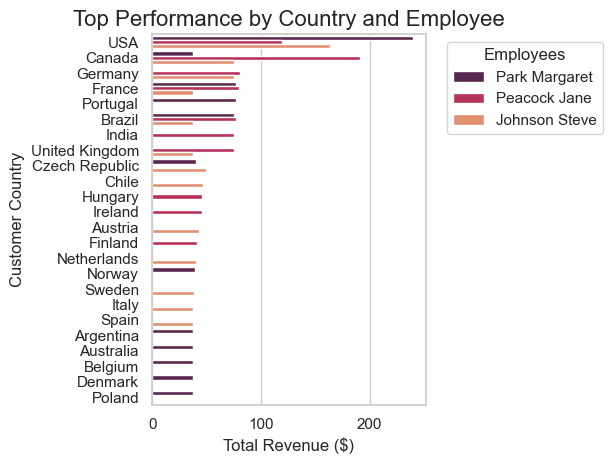

In [61]:
plt.Figure(figsize=(12 , 8))
sns.barplot(data=chinook_Top , x = 'Total_Sales' , y = 'Customer_Country' , hue='Employee_Name' , palette='rocket')
plt.title('Top Performance by Country and Employee' , fontsize = 16)
plt.xlabel('Total Revenue ($)' , fontsize = 12)
plt.ylabel('Customer Country' , fontsize = 12)
plt.legend(title = 'Employees' , bbox_to_anchor = (1.05 , 1) , loc = 'upper left')
plt.tight_layout()
plt.show()

## The Monthly Sales Performance

In [62]:
query = """ 
    SELECT CAST(strftime('%m' , InvoiceDate) AS INTEGER) AS Month , 
    SUM (i.Total) AS Total_Sales
    From Invoice i
    GROUP BY 1
    ORDER BY Month ;
"""
chinook_BestMonth = pd.read_sql(query , conn)
chinook_BestMonth

,Month,Total_Sales
0,1,201.12
1,2,187.20
2,3,195.10
3,4,198.14
4,5,193.10
5,6,201.10
6,7,190.10
7,8,198.10
8,9,196.20
9,10,193.10


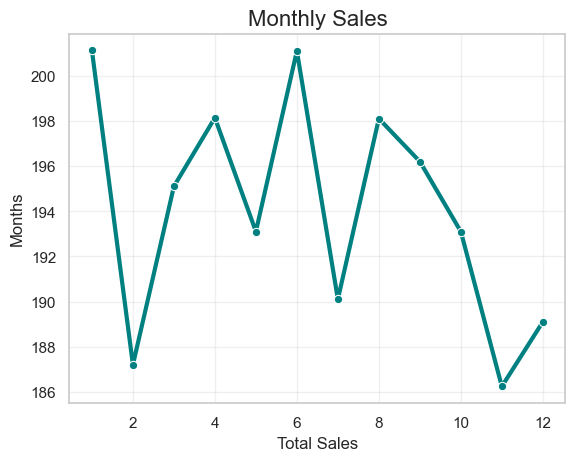

In [63]:
plt.Figure(figsize=(12 , 6 ))
sns.lineplot(data= chinook_BestMonth , x='Month' , y='Total_Sales' , marker = 'o' , linewidth = 3 , color = 'teal')
plt.title('Monthly Sales' , fontsize = 16)
plt.xlabel('Total Sales' , fontsize = 12)
plt.ylabel('Months' , fontsize = 12)
plt.grid(True , alpha = 0.3)
plt.show()

## Who are the top 10 best Customers

In [64]:
query = """ 
    SELECT c.FirstName || ' ' || c.LastName AS Customer_Name,
    SUM(i.Total) AS Total_Spend
    FROM Customer c
    JOIN Invoice i ON i.CustomerId = c.CustomerId
    GROUP BY c.CustomerId
    ORDER BY Total_Spend DESC 
    LIMIT 10 ;
"""
chinook_BestCustomer = pd.read_sql(query , conn)
chinook_BestCustomer

,Customer_Name,Total_Spend
0,Helena Holý,49.62
1,Richard Cunningham,47.62
2,Luis Rojas,46.62
3,Hugh O'Reilly,45.62
4,Ladislav Kovács,45.62
5,Fynn Zimmermann,43.62
6,Julia Barnett,43.62
7,Frank Ralston,43.62
8,Victor Stevens,42.62
9,Astrid Gruber,42.62


C:\Users\HP\AppData\Local\Temp\ipykernel_16664\1868740270.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chinook_BestCustomer , x='Customer_Name' , y='Total_Spend' , palette='Blues_r')


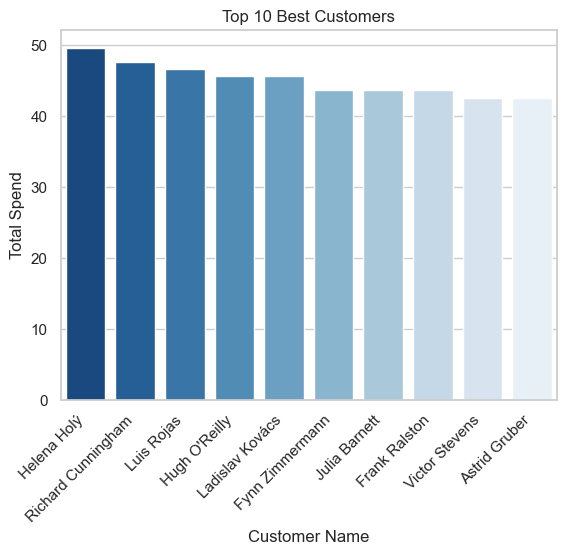

In [65]:
plt.Figure(figsize=(12 , 6))
sns.barplot(data=chinook_BestCustomer , x='Customer_Name' , y='Total_Spend' , palette='Blues_r')
plt.title('Top 10 Best Customers')
plt.xlabel('Customer Name')
plt.ylabel('Total Spend')
plt.xticks(rotation = 45 , ha = 'right')
plt.show()